# Weather-based Solar Simulation Benchmark

Notebook này được tổ chức lại theo 2 phần chính:

1. **Main benchmark**: backtest 5 năm cuối với **base physical case**.
2. **Physics sensitivity analysis**: chạy các case vật lý khác để phân tích what-if, không trộn vào benchmark chính.

Simulation hiện tại không mô phỏng trực tiếp `solar_gen_kwh`. Thay vào đó:

```text
historical hourly weather -> daily block weather simulation -> PV physical equation -> probabilistic forecast
```


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports and configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "/content/drive/MyDrive/TT/data/main/hourly/main.csv"
SOLAR_REF_ID = "AUS_SOLAR_REF_000"

TEST_YEARS = [2021, 2022, 2023, 2024, 2025]
N_SCENARIOS = 50
DOY_WINDOW = 3
CAPACITY_KWP = 6.6
RANDOM_STATE = 42

## 2. Load data

In [ ]:
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

print(df.shape)
df.head()

(87649, 14)


,solar_ref_id,date,lat,long,ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M,T_cell,temp_factor,solar_gen_kwh,day_of_year,month,hour
0,AUS_SOLAR_REF_000,2016-01-01 00:00:00,-27.832,114.852,0.0,24.35,2.52,59.43,24.35,1.002275,0.0,1,1,0
1,AUS_SOLAR_REF_000,2016-01-01 01:00:00,-27.832,114.852,0.0,24.20,2.08,59.74,24.20,1.002800,0.0,1,1,1
2,AUS_SOLAR_REF_000,2016-01-01 02:00:00,-27.832,114.852,0.0,23.87,1.59,60.87,23.87,1.003955,0.0,1,1,2
3,AUS_SOLAR_REF_000,2016-01-01 03:00:00,-27.832,114.852,0.0,23.35,0.96,62.82,23.35,1.005775,0.0,1,1,3
4,AUS_SOLAR_REF_000,2016-01-01 04:00:00,-27.832,114.852,0.0,22.73,0.86,65.02,22.73,1.007945,0.0,1,1,4


## 3. Physical cases

- `base` dùng cho benchmark chính.
- Các case còn lại dùng cho sensitivity / what-if analysis.


In [ ]:
BASE_CASE = {
    "case_name": "base",
    "pr": 0.80,
    "soiling_loss": 0.02,
    "degradation_loss": 0.01,
}

PHYSICS_CASES = [
    {
        "case_name": "clean_panel",
        "pr": 0.80,
        "soiling_loss": 0.00,
        "degradation_loss": 0.01,
    },
    {
        "case_name": "dirty_panel",
        "pr": 0.80,
        "soiling_loss": 0.06,
        "degradation_loss": 0.01,
    },
    {
        "case_name": "aged_panel",
        "pr": 0.80,
        "soiling_loss": 0.02,
        "degradation_loss": 0.05,
    },
]

pd.DataFrame(PHYSICS_CASES)

,case_name,pr,soiling_loss,degradation_loss
0,base,0.8,0.02,0.01
1,clean_panel,0.8,0.00,0.01
2,dirty_panel,0.8,0.06,0.01
3,aged_panel,0.8,0.02,0.05


## 4. PV calculation from simulated weather

In [ ]:
def calculate_solar_from_weather(
    df,
    capacity_kwp=6.6,
    pr=0.80,
    temp_coeff=-0.0035,
    soiling_loss=0.00,
    degradation_loss=0.00,
):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    effective_pr = pr * (1 - soiling_loss) * (1 - degradation_loss)

    # NOCT-based cell temperature approximation
    df['T_cell'] = df['T2M'] + (df['ALLSKY_SFC_SW_DWN'] / 800 * 25)
    df['temp_factor'] = 1 + temp_coeff * (df['T_cell'] - 25)

    df['solar_gen_kwh'] = (
        (df['ALLSKY_SFC_SW_DWN'] / 1000)
        * capacity_kwp
        * df['temp_factor']
        * effective_pr
    ).clip(lower=0)

    return df

## 5. Weather simulation with daily block sampling

Mỗi scenario được tạo bằng cách random chọn **nguyên 24 giờ thời tiết** từ một ngày lịch sử có `day_of_year` gần ngày cần mô phỏng.


In [ ]:
def simulate_weather_daily_blocks(
    df,
    solar_ref_id,
    start_date,
    days=365,
    n_scenarios=50,
    doy_window=7,
    random_state=42,
):
    rng = np.random.default_rng(random_state)

    data = df[df['solar_ref_id'] == solar_ref_id].copy()
    data['date'] = pd.to_datetime(data['date'])
    data['day'] = data['date'].dt.floor('D')
    data['day_of_year'] = data['date'].dt.dayofyear
    data['hour'] = data['date'].dt.hour

    weather_cols = ['ALLSKY_SFC_SW_DWN', 'T2M', 'WS2M', 'RH2M']
    weather_cols = [c for c in weather_cols if c in data.columns]

    keep_base_cols = ['solar_ref_id', 'day', 'day_of_year', 'hour'] + weather_cols
    for col in ['lat', 'long']:
        if col in data.columns:
            keep_base_cols.append(col)

    data = data[keep_base_cols].copy()

    day_meta = (
        data.groupby('day')
        .agg(day_of_year=('day_of_year', 'first'))
        .reset_index()
    )

    # Precompute candidate historical days for each DOY to avoid repeated filtering.
    candidate_days_by_doy = {}
    for doy in range(1, 367):
        distance = np.minimum(
            np.abs(day_meta['day_of_year'] - doy),
            365 - np.abs(day_meta['day_of_year'] - doy)
        )
        candidates = day_meta.loc[distance <= doy_window, 'day'].to_numpy()
        if len(candidates) == 0:
            candidates = day_meta['day'].to_numpy()
        candidate_days_by_doy[doy] = candidates

    # Precompute daily blocks.
    blocks = {
        day: block.sort_values('hour').head(24).copy()
        for day, block in data.groupby('day')
    }

    future_days = pd.date_range(start=start_date, periods=days, freq='D')
    all_scenarios = []

    for scenario_id in range(n_scenarios):
        scenario_parts = []

        for future_day in future_days:
            doy = future_day.dayofyear
            sampled_day = rng.choice(candidate_days_by_doy[doy])
            sampled_day = pd.Timestamp(sampled_day)
            block = blocks[sampled_day].copy()

            block['scenario_id'] = scenario_id
            block['date'] = future_day + pd.to_timedelta(block['hour'], unit='h')
            block['day_of_year'] = block['date'].dt.dayofyear
            block['month'] = block['date'].dt.month

            keep_cols = [
                'scenario_id', 'solar_ref_id', 'date',
                'day_of_year', 'month', 'hour'
            ] + weather_cols

            for col in ['lat', 'long']:
                if col in block.columns:
                    keep_cols.append(col)

            scenario_parts.append(block[keep_cols])

        all_scenarios.append(pd.concat(scenario_parts, ignore_index=True))

    return pd.concat(all_scenarios, ignore_index=True)

## 6. Weather simulation → probabilistic solar forecast

In [ ]:
def simulate_solar_daily_blocks(
    df,
    solar_ref_id,
    start_date,
    days=365,
    n_scenarios=50,
    doy_window=7,
    capacity_kwp=6.6,
    pr=0.80,
    temp_coeff=-0.0035,
    soiling_loss=0.00,
    degradation_loss=0.00,
    random_state=42,
    return_scenarios=False,
):
    weather_sim = simulate_weather_daily_blocks(
        df=df,
        solar_ref_id=solar_ref_id,
        start_date=start_date,
        days=days,
        n_scenarios=n_scenarios,
        doy_window=doy_window,
        random_state=random_state,
    )

    solar_sim = calculate_solar_from_weather(
        weather_sim,
        capacity_kwp=capacity_kwp,
        pr=pr,
        temp_coeff=temp_coeff,
        soiling_loss=soiling_loss,
        degradation_loss=degradation_loss,
    )

    forecast = (
        solar_sim
        .groupby(['solar_ref_id', 'date'])
        .agg(
            q0_1=('solar_gen_kwh', lambda x: x.quantile(0.1)),
            q0_5=('solar_gen_kwh', lambda x: x.quantile(0.5)),
            q0_9=('solar_gen_kwh', lambda x: x.quantile(0.9)),
            mean_simulation=('solar_gen_kwh', 'mean'),
            mean_irradiance=('ALLSKY_SFC_SW_DWN', 'mean'),
            mean_T2M=('T2M', 'mean'),
        )
        .reset_index()
    )

    if return_scenarios:
        return forecast, solar_sim

    return forecast

## 7. Evaluation metrics

In [ ]:
def evaluate_forecast(eval_df):
    y = eval_df['solar_gen_kwh']
    pred = eval_df['q0_5']

    mae = np.mean(np.abs(y - pred))
    rmse = np.sqrt(np.mean((y - pred) ** 2))

    smape = np.mean(
        2 * np.abs(pred - y) / (np.abs(y) + np.abs(pred) + 1e-8)
    ) * 100

    coverage_80 = np.mean(
        (y >= eval_df['q0_1']) & (y <= eval_df['q0_9'])
    ) * 100

    interval_width = np.mean(eval_df['q0_9'] - eval_df['q0_1'])

    return {
        'MAE': mae,
        'RMSE': rmse,
        'sMAPE': smape,
        'Coverage_80': coverage_80,
        'Interval_Width': interval_width,
    }


def evaluate_daylight_only(eval_df, threshold=0.05):
    daylight_df = eval_df[eval_df['solar_gen_kwh'] > threshold].copy()
    metrics = evaluate_forecast(daylight_df)
    metrics = {f'daylight_{k}': v for k, v in metrics.items()}
    return metrics

## 8. Backtest functions

In [ ]:
def backtest_one_year(
    df,
    solar_ref_id,
    test_year,
    n_scenarios=50,
    doy_window=7,
    capacity_kwp=6.6,
    pr=0.80,
    soiling_loss=0.02,
    degradation_loss=0.01,
    random_state=42,
):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    train_df = df[
        (df['solar_ref_id'] == solar_ref_id) &
        (df['date'].dt.year < test_year)
    ].copy()

    test_df = df[
        (df['solar_ref_id'] == solar_ref_id) &
        (df['date'].dt.year == test_year)
    ].copy()

    forecast = simulate_solar_daily_blocks(
        df=train_df,
        solar_ref_id=solar_ref_id,
        start_date=f'{test_year}-01-01',
        days=365,
        n_scenarios=n_scenarios,
        doy_window=doy_window,
        capacity_kwp=capacity_kwp,
        pr=pr,
        soiling_loss=soiling_loss,
        degradation_loss=degradation_loss,
        random_state=random_state,
        return_scenarios=False,
    )

    actual = test_df[['solar_ref_id', 'date', 'solar_gen_kwh']].copy()

    eval_df = forecast.merge(
        actual,
        on=['solar_ref_id', 'date'],
        how='inner',
    )

    metrics = evaluate_forecast(eval_df)
    metrics.update(evaluate_daylight_only(eval_df))

    metrics['test_year'] = test_year
    metrics['solar_ref_id'] = solar_ref_id
    metrics['n_scenarios'] = n_scenarios
    metrics['doy_window'] = doy_window
    metrics['pr'] = pr
    metrics['soiling_loss'] = soiling_loss
    metrics['degradation_loss'] = degradation_loss

    return metrics, eval_df


def run_backtest_for_case(
    df,
    solar_ref_id,
    test_years,
    case,
    n_scenarios=50,
    doy_window=7,
    capacity_kwp=6.6,
    random_state=42,
    keep_eval=True,
):
    results = []
    eval_parts = []

    for year in test_years:
        print(f"Running {case['case_name']} | year={year}")

        metrics, eval_df = backtest_one_year(
            df=df,
            solar_ref_id=solar_ref_id,
            test_year=year,
            n_scenarios=n_scenarios,
            doy_window=doy_window,
            capacity_kwp=capacity_kwp,
            pr=case['pr'],
            soiling_loss=case['soiling_loss'],
            degradation_loss=case['degradation_loss'],
            random_state=random_state + year,
        )

        metrics['case_name'] = case['case_name']
        results.append(metrics)

        if keep_eval:
            eval_df['test_year'] = year
            eval_df['case_name'] = case['case_name']
            eval_parts.append(eval_df)

    result_df = pd.DataFrame(results)
    eval_all_df = pd.concat(eval_parts, ignore_index=True) if keep_eval else None

    return result_df, eval_all_df

## 9. Main benchmark: base case only

Đây là benchmark chính để đánh giá chất lượng simulation.


In [ ]:
base_benchmark_df, base_eval_df = run_backtest_for_case(
    df=df,
    solar_ref_id=SOLAR_REF_ID,
    test_years=TEST_YEARS,
    case=BASE_CASE,
    n_scenarios=N_SCENARIOS,
    doy_window=DOY_WINDOW,
    capacity_kwp=CAPACITY_KWP,
    random_state=RANDOM_STATE,
    keep_eval=True,
)

base_benchmark_df

Running base | year=2021
Running base | year=2022
Running base | year=2023
Running base | year=2024
Running base | year=2025


,MAE,RMSE,sMAPE,Coverage_80,Interval_Width,daylight_MAE,daylight_RMSE,daylight_sMAPE,daylight_Coverage_80,daylight_Interval_Width,test_year,solar_ref_id,n_scenarios,doy_window,pr,soiling_loss,degradation_loss,case_name
0,0.144363,0.320518,7.725955,78.036530,0.393247,0.285780,0.451156,14.678576,56.910201,0.778629,2021,AUS_SOLAR_REF_000,50,3,0.8,0.02,0.01,base
1,0.143489,0.334987,7.728178,79.577626,0.388399,0.284039,0.471523,14.635503,60.076906,0.768999,2022,AUS_SOLAR_REF_000,50,3,0.8,0.02,0.01,base
2,0.111550,0.246460,6.026335,82.716895,0.393156,0.221153,0.347154,11.490487,66.070215,0.779491,2023,AUS_SOLAR_REF_000,50,3,0.8,0.02,0.01,base
3,0.137791,0.325134,7.468784,81.689498,0.379970,0.273228,0.458069,14.196864,64.174031,0.753610,2024,AUS_SOLAR_REF_000,50,3,0.8,0.02,0.01,base
4,0.130557,0.289065,6.949852,78.230514,0.381925,0.258264,0.406682,13.179156,57.181695,0.755460,2025,AUS_SOLAR_REF_000,50,3,0.8,0.02,0.01,base


In [ ]:
base_benchmark_summary = (
    base_benchmark_df
    .drop(columns=['test_year'], errors='ignore')
    .mean(numeric_only=True)
    .to_frame('mean_value')
)

base_benchmark_summary

,mean_value
MAE,0.133550
RMSE,0.303233
sMAPE,7.179821
Coverage_80,80.050212
Interval_Width,0.387339
daylight_MAE,0.264493
daylight_RMSE,0.426917
daylight_sMAPE,13.636117
daylight_Coverage_80,60.882610
daylight_Interval_Width,0.767238


## 10. Physics sensitivity benchmark

Phần này dùng để phân tích what-if. Không dùng để thay thế benchmark chính.


In [ ]:
physics_results = []

for case in PHYSICS_CASES:
    case_result_df, _ = run_backtest_for_case(
        df=df,
        solar_ref_id=SOLAR_REF_ID,
        test_years=TEST_YEARS,
        case=case,
        n_scenarios=N_SCENARIOS,
        doy_window=DOY_WINDOW,
        capacity_kwp=CAPACITY_KWP,
        random_state=RANDOM_STATE,
        keep_eval=False,
    )
    physics_results.append(case_result_df)

physics_benchmark_df = pd.concat(physics_results, ignore_index=True)
physics_benchmark_df

Running base | year=2021
Running base | year=2022
Running base | year=2023
Running base | year=2024
Running base | year=2025
Running clean_panel | year=2021
Running clean_panel | year=2022
Running clean_panel | year=2023
Running clean_panel | year=2024
Running clean_panel | year=2025
Running dirty_panel | year=2021
Running dirty_panel | year=2022
Running dirty_panel | year=2023
Running dirty_panel | year=2024
Running dirty_panel | year=2025
Running aged_panel | year=2021
Running aged_panel | year=2022
Running aged_panel | year=2023
Running aged_panel | year=2024
Running aged_panel | year=2025


,MAE,RMSE,sMAPE,Coverage_80,Interval_Width,daylight_MAE,daylight_RMSE,daylight_sMAPE,daylight_Coverage_80,daylight_Interval_Width,test_year,solar_ref_id,n_scenarios,doy_window,pr,soiling_loss,degradation_loss,case_name
0,0.144363,0.320518,7.725955,78.036530,0.393247,0.285780,0.451156,14.678576,56.910201,0.778629,2021,AUS_SOLAR_REF_000,50,3,0.8,0.02,0.01,base
1,0.143489,0.334987,7.728178,79.577626,0.388399,0.284039,0.471523,14.635503,60.076906,0.768999,2022,AUS_SOLAR_REF_000,50,3,0.8,0.02,0.01,base
2,0.111550,0.246460,6.026335,82.716895,0.393156,0.221153,0.347154,11.490487,66.070215,0.779491,2023,AUS_SOLAR_REF_000,50,3,0.8,0.02,0.01,base
3,0.137791,0.325134,7.468784,81.689498,0.379970,0.273228,0.458069,14.196864,64.174031,0.753610,2024,AUS_SOLAR_REF_000,50,3,0.8,0.02,0.01,base
4,0.130557,0.289065,6.949852,78.230514,0.381925,0.258264,0.406682,13.179156,57.181695,0.755460,2025,AUS_SOLAR_REF_000,50,3,0.8,0.02,0.01,base
5,0.140690,0.328905,7.591028,83.093607,0.401273,0.278495,0.462961,14.405426,66.930559,0.794520,2021,AUS_SOLAR_REF_000,50,3,0.8,0.00,0.01,clean_panel
6,0.137360,0.342707,7.516256,85.365297,0.396326,0.271886,0.482390,14.206189,71.544899,0.784693,2022,AUS_SOLAR_REF_000,50,3,0.8,0.00,0.01,clean_panel
7,0.106529,0.250438,5.845264,89.075342,0.401179,0.211185,0.352758,11.130611,78.640997,0.795399,2023,AUS_SOLAR_REF_000,50,3,0.8,0.00,0.01,clean_panel
8,0.133461,0.334734,7.317711,87.397260,0.387724,0.264624,0.471594,13.891213,75.549513,0.768990,2024,AUS_SOLAR_REF_000,50,3,0.8,0.00,0.01,clean_panel
9,0.125052,0.294995,6.726455,84.937622,0.389720,0.247366,0.415025,12.740572,70.457635,0.770878,2025,AUS_SOLAR_REF_000,50,3,0.8,0.00,0.01,clean_panel


In [ ]:
physics_summary_df = (
    physics_benchmark_df
    .groupby('case_name')
    .agg(
        MAE=('MAE', 'mean'),
        RMSE=('RMSE', 'mean'),
        sMAPE=('sMAPE', 'mean'),
        Coverage_80=('Coverage_80', 'mean'),
        Interval_Width=('Interval_Width', 'mean'),
        daylight_MAE=('daylight_MAE', 'mean'),
        daylight_RMSE=('daylight_RMSE', 'mean'),
        daylight_sMAPE=('daylight_sMAPE', 'mean'),
    )
    .reset_index()
)

physics_summary_df

,case_name,MAE,RMSE,sMAPE,Coverage_80,Interval_Width,daylight_MAE,daylight_RMSE,daylight_sMAPE
0,aged_panel,0.152605,0.305569,7.884437,69.501989,0.371689,0.302274,0.430207,15.031220
1,base,0.133550,0.303233,7.179821,80.050212,0.387339,0.264493,0.426917,13.636117
2,clean_panel,0.128618,0.310356,6.999343,85.973826,0.395244,0.254711,0.436946,13.274802
3,dirty_panel,0.152838,0.305705,7.893318,69.419779,0.371530,0.302738,0.430399,15.048762


## 11. Plots

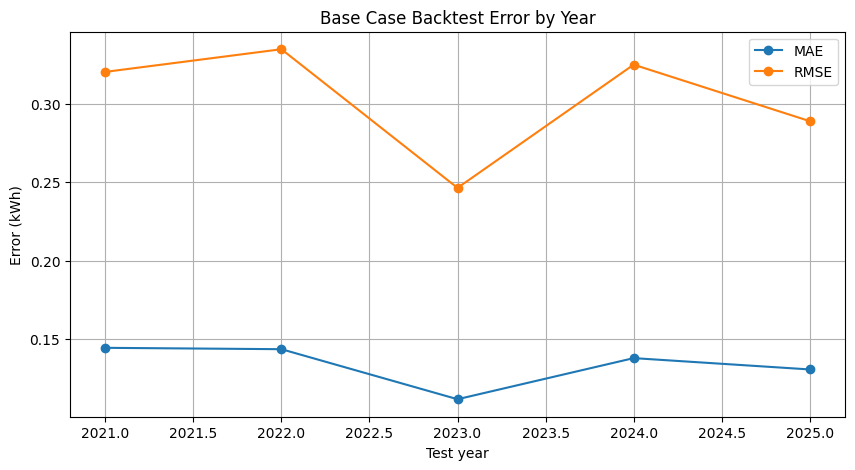

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(base_benchmark_df['test_year'], base_benchmark_df['MAE'], marker='o', label='MAE')
plt.plot(base_benchmark_df['test_year'], base_benchmark_df['RMSE'], marker='o', label='RMSE')
plt.xlabel('Test year')
plt.ylabel('Error (kWh)')
plt.title('Base Case Backtest Error by Year')
plt.legend()
plt.grid(True)
plt.show()

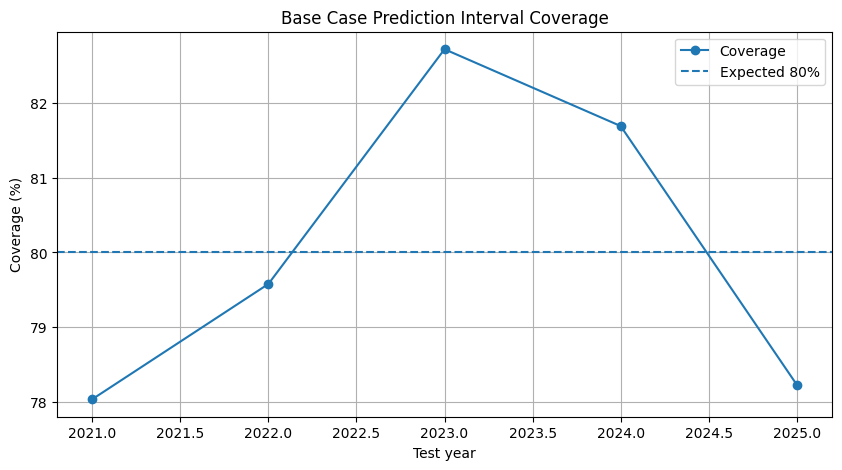

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(base_benchmark_df['test_year'], base_benchmark_df['Coverage_80'], marker='o', label='Coverage')
plt.axhline(80, linestyle='--', label='Expected 80%')
plt.xlabel('Test year')
plt.ylabel('Coverage (%)')
plt.title('Base Case Prediction Interval Coverage')
plt.legend()
plt.grid(True)
plt.show()

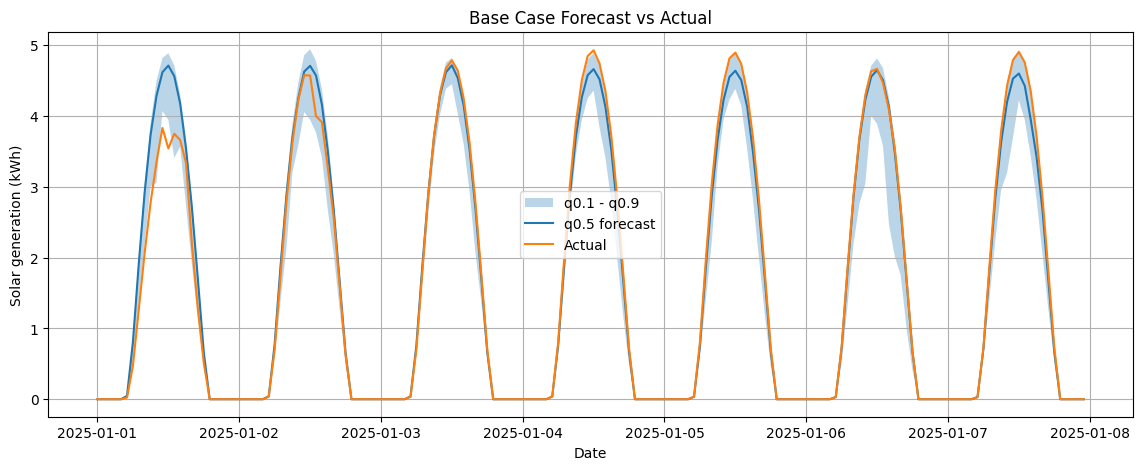

In [ ]:
plot_df = base_eval_df[base_eval_df['test_year'] == 2025].copy()
plot_df['date'] = pd.to_datetime(plot_df['date'])

# Change the date range if needed.
plot_df = plot_df[
    (plot_df['date'] >= '2025-01-01') &
    (plot_df['date'] < '2025-01-08')
]

plt.figure(figsize=(14, 5))
plt.fill_between(
    plot_df['date'],
    plot_df['q0_1'],
    plot_df['q0_9'],
    alpha=0.3,
    label='q0.1 - q0.9',
)
plt.plot(plot_df['date'], plot_df['q0_5'], label='q0.5 forecast')
plt.plot(plot_df['date'], plot_df['solar_gen_kwh'], label='Actual')
plt.xlabel('Date')
plt.ylabel('Solar generation (kWh)')
plt.title('Base Case Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()

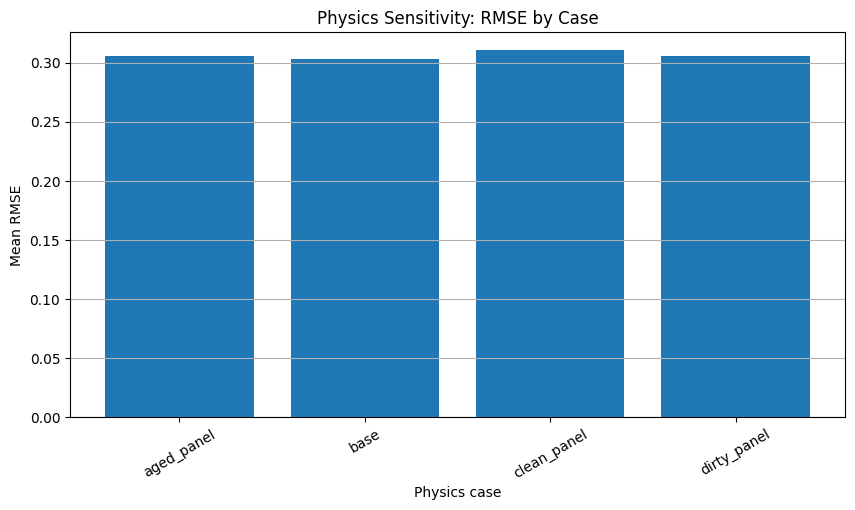

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(physics_summary_df['case_name'], physics_summary_df['RMSE'])
plt.xlabel('Physics case')
plt.ylabel('Mean RMSE')
plt.title('Physics Sensitivity: RMSE by Case')
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.show()

## 12. Optional: Forecast 2026 with selected physics case

Chỉ chạy phần này khi cần mô phỏng năm 2026. Không dùng cho benchmark vì chưa có actual.


## 13. Save outputs

In [ ]:
# OUTPUT_DIR = "/content/drive/MyDrive/TT/data/main/simulation_results"
# import os
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# base_benchmark_df.to_csv(f"{OUTPUT_DIR}/base_benchmark.csv", index=False)
# base_eval_df.to_csv(f"{OUTPUT_DIR}/base_eval_hourly.csv", index=False)
# physics_benchmark_df.to_csv(f"{OUTPUT_DIR}/physics_benchmark.csv", index=False)
# physics_summary_df.to_csv(f"{OUTPUT_DIR}/physics_summary.csv", index=False)